# Baryquark Demo

This notebook now does two things:

1. compares **Clausius quarkyonic** against **Clausius baryquark** in symmetric matter
2. reproduces the **symmetric EOS** for the excluded-volume models `vdw`, `cs`, and `tvm`

The notebook runs the `QMM` solver with `write_plots = false` and then builds the figures directly in the notebook from the saved CSV tables. That avoids depending on `matplotlib` inside the `qmm` runtime interpreter.


In [1]:
from pathlib import Path
import json
import os
import shutil
import subprocess
import sys
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
QMM_ROOT = ROOT / 'QMM' if (ROOT / 'QMM').exists() else ROOT
preferred_python = Path('/opt/homebrew/bin/python3.12')
PYTHON = str(preferred_python) if preferred_python.exists() else (shutil.which('python3.12') or sys.executable)

MOMENTUM_MODE = 'baryquark'   # change to 'quarkyonic' if you want the standard filling
LAMBDA_MEV = 300.0
QUICK = True

print('QMM root:', QMM_ROOT)
print('Python executable:', PYTHON)
print('Momentum mode for the excluded-volume comparison:', MOMENTUM_MODE)


QMM root: /Users/dajuarez4/Documents/QuarkMatt/QMM
Python executable: /opt/anaconda3/envs/tovsolver/bin/python3
Momentum mode for the excluded-volume comparison: baryquark


## Helpers

The helper below generates a temporary JSON input, runs `qmm`, and returns the summary and symmetric curve table.


In [2]:
def build_symmetric_config(model_name: str, run_name: str, momentum_mode: str, lambda_mev: float = 300.0, quick: bool = True, quarkyonic_overrides=None):
    config = {
        'run_name': run_name,
        'model': {'name': model_name},
        'workflows': {
            'ground_state': True,
            'quantum_critical': False,
            'hadronic_eos_table': False,
            'symmetric_quarkyonic': True,
            'asymmetric_fit': False,
            'asymmetric_quarkyonic': False,
            'neutron_star': False,
        },
        'quarkyonic': {
            'quick': quick,
            'momentum_mode': momentum_mode,
            'lambda_momentum_mev': lambda_mev,
        },
        'output': {
            'directory': f'results/generated/{run_name}',
            'write_json': True,
            'write_csv': True,
            'write_plots': False,
        },
    }

    if quarkyonic_overrides:
        config['quarkyonic'].update(quarkyonic_overrides)

    if model_name == 'clausius':
        config['model']['parameter_search'] = {
            'enabled': True,
            'target_k0': 280.0,
            'parameter_min': 0.0,
            'parameter_max': 4.74,
            'scan_steps': 81,
        }

    return config


def run_symmetric_mode(model_name: str, run_name: str, momentum_mode: str, lambda_mev: float = 300.0, quick: bool = True, quarkyonic_overrides=None):
    data = build_symmetric_config(
        model_name,
        run_name,
        momentum_mode,
        lambda_mev=lambda_mev,
        quick=quick,
        quarkyonic_overrides=quarkyonic_overrides,
    )

    with tempfile.NamedTemporaryFile('w', suffix='.json', delete=False) as handle:
        json.dump(data, handle)
        temp_json = handle.name

    env = dict(os.environ)
    env['PYTHONPATH'] = 'src'
    result = subprocess.run(
        [PYTHON, '-m', 'qmm', temp_json],
        cwd=QMM_ROOT,
        env=env,
        capture_output=True,
        text=True,
        check=True,
    )
    print(result.stdout)

    out_dir = QMM_ROOT / 'results' / 'generated' / run_name
    summary = json.loads((out_dir / f'{run_name}_summary.json').read_text())
    curve = pd.read_csv(out_dir / f'{run_name}_symmetric_quarkyonic_curve.csv')
    return summary, curve


def energy_per_baryon_gev(curve_df: pd.DataFrame) -> pd.Series:
    return curve_df['eps'] / curve_df['n'] / 1000.0 - 0.939


## Clausius: Quarkyonic Versus Baryquark

The two runs below use the same Clausius model and the same `K_0 = 280 MeV` target. Only the momentum-space filling changes.


In [3]:
clausius_bq_summary, clausius_bq_curve = run_symmetric_mode(
    model_name='clausius',
    run_name='clausius_baryquark_demo_notebook',
    momentum_mode='baryquark',
    lambda_mev=LAMBDA_MEV,
    quick=QUICK,
)

clausius_qy_summary, clausius_qy_curve = run_symmetric_mode(
    model_name='clausius',
    run_name='clausius_quarkyonic_demo_notebook',
    momentum_mode='quarkyonic',
    lambda_mev=LAMBDA_MEV,
    quick=QUICK,
)

pd.DataFrame([
    {
        'mode': 'baryquark',
        'parameter_value': clausius_bq_summary['symmetric_quarkyonic']['parameter_value'],
        'K0_MeV': clausius_bq_summary['symmetric_quarkyonic']['K0'],
        'n_tr_over_n0': clausius_bq_summary['symmetric_quarkyonic']['n_tr_over_n0'],
        'vs2_max': clausius_bq_summary['symmetric_quarkyonic']['vs2_max'],
    },
    {
        'mode': 'quarkyonic',
        'parameter_value': clausius_qy_summary['symmetric_quarkyonic']['parameter_value'],
        'K0_MeV': clausius_qy_summary['symmetric_quarkyonic']['K0'],
        'n_tr_over_n0': clausius_qy_summary['symmetric_quarkyonic']['n_tr_over_n0'],
        'vs2_max': clausius_qy_summary['symmetric_quarkyonic']['vs2_max'],
    },
])


{
  "ground_state": {
    "K0": 280.0000001057512,
    "a": 454.4126972453143,
    "b": 1.936449726194465,
    "binding": -16.00000000011221,
    "e_per_particle_minus_m_at_sat": -16.00000000011096,
    "eps_id": 223.90949035007523,
    "kf": 1.508407605443754,
    "model": "clausius",
    "n_id": 0.23182759827156763,
    "n_sat": 0.15999997361210014,
    "p_id": 4.230450216438622,
    "p_sat": -8.209566368932997e-07,
    "parameter_name": "c",
    "parameter_value": 4.114108112409712
  },
  "model": {
    "name": "clausius",
    "parameter_search": {
      "enabled": true,
      "parameter_max": 4.74,
      "parameter_min": 0.0,
      "scan_steps": 81,
      "target_k0": 280.0,
      "tol": 1e-08
    },
    "parameter_value": null
  },
  "outputs": {
    "ground_state_csv": "results/generated/clausius_baryquark_demo_notebook/clausius_baryquark_demo_notebook_ground_state.csv",
    "summary_json": "results/generated/clausius_baryquark_demo_notebook/clausius_baryquark_demo_notebook_summa

,mode,parameter_value,K0_MeV,n_tr_over_n0,vs2_max
0,baryquark,4.114108,280.0,2.067797,0.359710
1,quarkyonic,4.114108,280.0,2.542373,0.656885


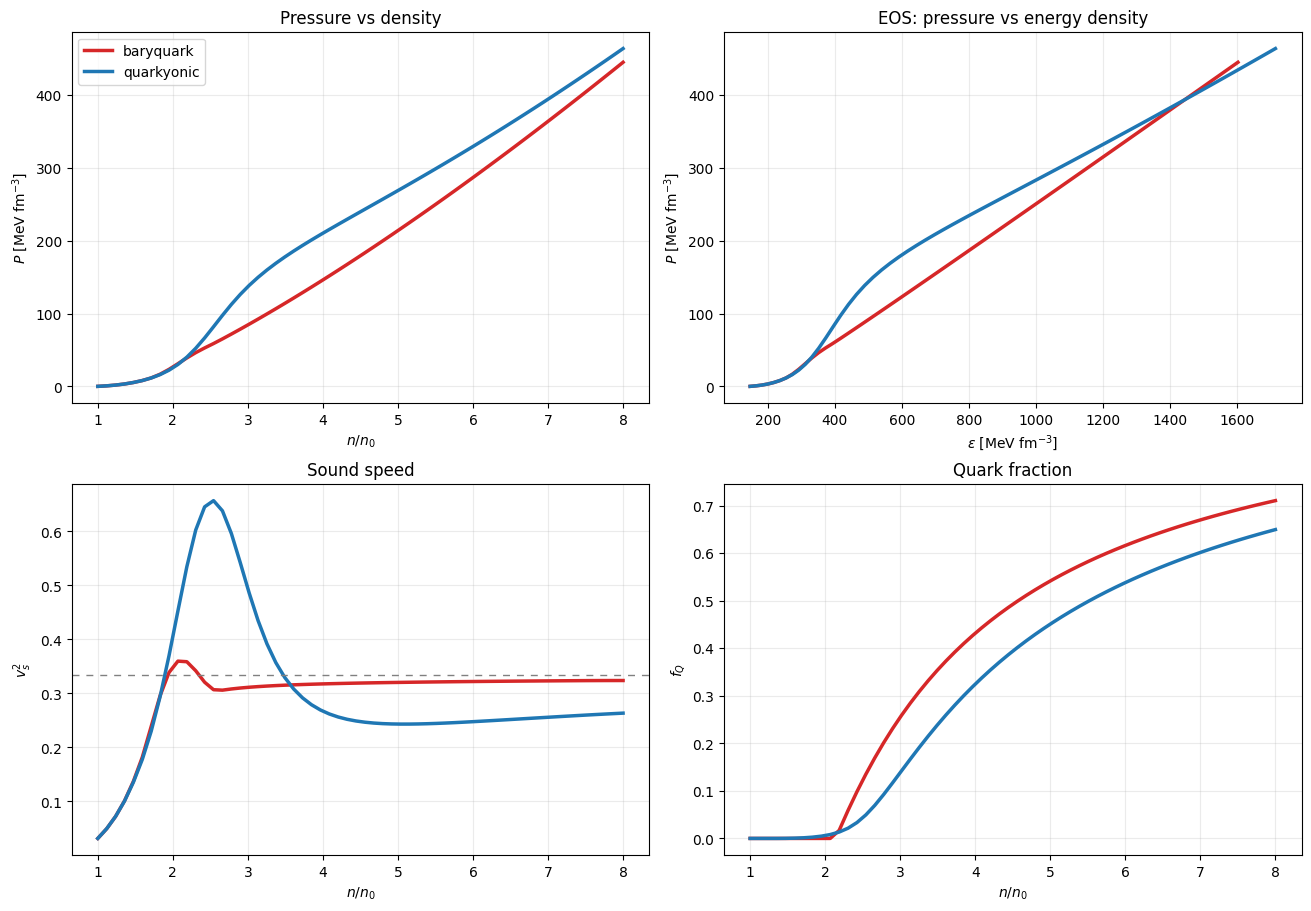

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)
ax_eos_n, ax_p_eps, ax_vs, ax_fq = axes.flat

for label, df, color in [
    ('baryquark', clausius_bq_curve, '#d62728'),
    ('quarkyonic', clausius_qy_curve, '#1f77b4'),
]:
    x = df['n_over_n0']
    ax_eos_n.plot(x, df['pressure'], lw=2.5, color=color, label=label)
    ax_p_eps.plot(df['eps'], df['pressure'], lw=2.5, color=color, label=label)
    ax_vs.plot(x, df['vs2'], lw=2.5, color=color, label=label)
    ax_fq.plot(x, df['quark_fraction'], lw=2.5, color=color, label=label)

ax_eos_n.set_xlabel(r'$n/n_0$')
ax_eos_n.set_ylabel(r'$P$ [MeV fm$^{-3}$]')
ax_eos_n.set_title('Pressure vs density')
ax_eos_n.grid(alpha=0.25)
ax_eos_n.legend()

ax_p_eps.set_xlabel(r'$\epsilon$ [MeV fm$^{-3}$]')
ax_p_eps.set_ylabel(r'$P$ [MeV fm$^{-3}$]')
ax_p_eps.set_title('EOS: pressure vs energy density')
ax_p_eps.grid(alpha=0.25)

ax_vs.set_xlabel(r'$n/n_0$')
ax_vs.set_ylabel(r'$v_s^2$')
ax_vs.axhline(1.0/3.0, color='gray', ls=(0, (5, 5)), lw=1.0)
ax_vs.set_title('Sound speed')
ax_vs.grid(alpha=0.25)

ax_fq.set_xlabel(r'$n/n_0$')
ax_fq.set_ylabel(r'$f_Q$')
ax_fq.set_title('Quark fraction')
ax_fq.grid(alpha=0.25)


## Symmetric Excluded-Volume Comparison: `vdw`, `cs`, `tvm`

The next block reproduces the symmetric solver for the three excluded-volume prescriptions.

The momentum mode is controlled by `MOMENTUM_MODE` at the top of the notebook. Right now it is set to the same mode used for the baryquark study.


In [5]:
symmetric_results = {}
for model_name in ['vdw', 'cs', 'tvm']:
    run_name = f'{model_name}_{MOMENTUM_MODE}_symmetric_notebook'
    summary, curve = run_symmetric_mode(
        model_name=model_name,
        run_name=run_name,
        momentum_mode=MOMENTUM_MODE,
        lambda_mev=LAMBDA_MEV,
        quick=QUICK,
    )
    symmetric_results[model_name] = {'summary': summary, 'curve': curve}

pd.DataFrame([
    {
        'model': model_name,
        'momentum_mode': result['summary']['symmetric_quarkyonic']['momentum_mode'],
        'K0_MeV': result['summary']['symmetric_quarkyonic']['K0'],
        'n_tr_over_n0': result['summary']['symmetric_quarkyonic']['n_tr_over_n0'],
        'vs2_max': result['summary']['symmetric_quarkyonic']['vs2_max'],
    }
    for model_name, result in symmetric_results.items()
])


{
  "ground_state": {
    "K0": 762.5389525731663,
    "a": 328.9233214199405,
    "b": 3.4140201144371347,
    "binding": -16.000000000473165,
    "e_per_particle_minus_m_at_sat": -16.000000000473165,
    "eps_id": 343.66524825802145,
    "kf": 1.73471960241986,
    "model": "vdw",
    "n_id": 0.3526118097983361,
    "n_sat": 0.15999999607708937,
    "p_id": 8.420437028350477,
    "p_sat": -3.32374369804711e-07,
    "parameter_name": null,
    "parameter_value": null
  },
  "model": {
    "name": "vdw",
    "parameter_search": {
      "enabled": false,
      "parameter_max": null,
      "parameter_min": null,
      "scan_steps": 121,
      "target_k0": null,
      "tol": 1e-08
    },
    "parameter_value": null
  },
  "outputs": {
    "ground_state_csv": "results/generated/vdw_baryquark_symmetric_notebook/vdw_baryquark_symmetric_notebook_ground_state.csv",
    "summary_json": "results/generated/vdw_baryquark_symmetric_notebook/vdw_baryquark_symmetric_notebook_summary.json",
    "symme

,model,momentum_mode,K0_MeV,n_tr_over_n0,vs2_max
0,vdw,baryquark,762.538953,1.237288,0.424398
1,cs,baryquark,601.449391,1.593220,0.424030
2,tvm,baryquark,564.221282,1.593220,0.446447


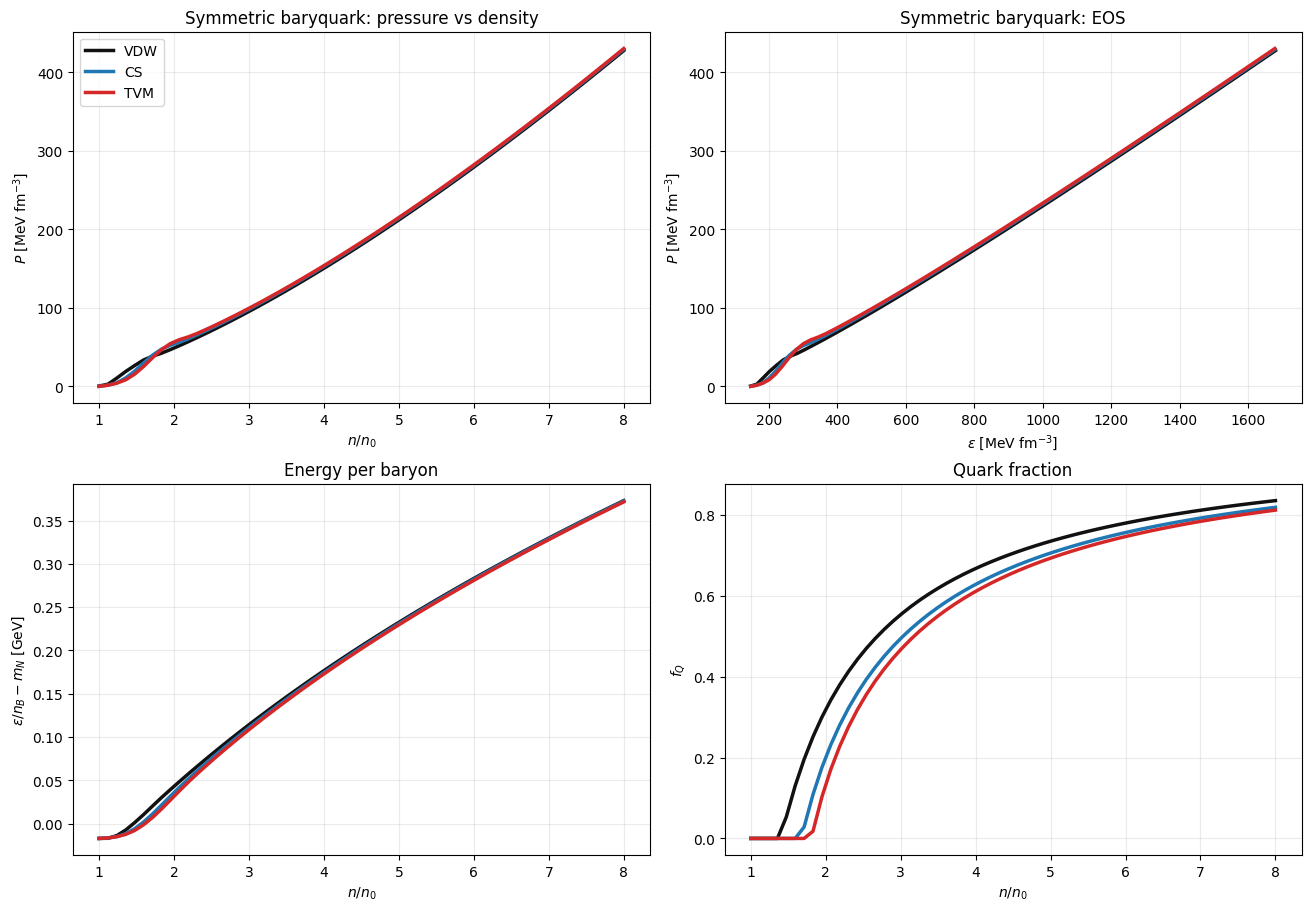

In [6]:
colors = {
    'vdw': '#111111',
    'cs': '#1f77b4',
    'tvm': '#d62728',
}

fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)
ax_pressure_n, ax_pressure_eps, ax_energy_n, ax_fq = axes.flat

for model_name, result in symmetric_results.items():
    df = result['curve']
    color = colors[model_name]
    x = df['n_over_n0']
    ax_pressure_n.plot(x, df['pressure'], lw=2.5, color=color, label=model_name.upper())
    ax_pressure_eps.plot(df['eps'], df['pressure'], lw=2.5, color=color, label=model_name.upper())
    ax_energy_n.plot(x, energy_per_baryon_gev(df), lw=2.5, color=color, label=model_name.upper())
    ax_fq.plot(x, df['quark_fraction'], lw=2.5, color=color, label=model_name.upper())

ax_pressure_n.set_xlabel(r'$n/n_0$')
ax_pressure_n.set_ylabel(r'$P$ [MeV fm$^{-3}$]')
ax_pressure_n.set_title(f'Symmetric {MOMENTUM_MODE}: pressure vs density')
ax_pressure_n.grid(alpha=0.25)
ax_pressure_n.legend()

ax_pressure_eps.set_xlabel(r'$\epsilon$ [MeV fm$^{-3}$]')
ax_pressure_eps.set_ylabel(r'$P$ [MeV fm$^{-3}$]')
ax_pressure_eps.set_title(f'Symmetric {MOMENTUM_MODE}: EOS')
ax_pressure_eps.grid(alpha=0.25)

ax_energy_n.set_xlabel(r'$n/n_0$')
ax_energy_n.set_ylabel(r'$\epsilon/n_B - m_N$ [GeV]')
ax_energy_n.set_title('Energy per baryon')
ax_energy_n.grid(alpha=0.25)

ax_fq.set_xlabel(r'$n/n_0$')
ax_fq.set_ylabel(r'$f_Q$')
ax_fq.set_title('Quark fraction')
ax_fq.grid(alpha=0.25)


## Notes

- If you want the standard symmetric comparison instead of baryquark, change `MOMENTUM_MODE = 'quarkyonic'` in the first code cell and rerun the notebook.
- The curves are built from the saved symmetric CSV tables written by `qmm`.
- This notebook uses the same `lambda_momentum_mev = 300 MeV` for the symmetric comparison block.


## Paper-Style Replication: Symmetric `vdw`, `cs`, `tvm`

This section reproduces the **main structure** of the figure you shared using the local `QMM` implementation.

It uses:

- symmetric matter only
- `\Lambda = 0.2\,\mathrm{GeV}`
- top row: `quarkyonic`
- bottom row: `baryquark`
- models: `vdw`, `cs`, `tvm`

The three plotted observables are:

1. `\epsilon/n_B - m_N`
2. `n_Q/n_B = f_Q`
3. `v_s^2`

Note:
- the current **`vdw`** curve already includes the standard van der Waals attractive mean field
  `U(n_N) = -n_N`, which enters the energy density as `a U(n_N) = -a n_N`
- the extra control curve labeled **`vdW excl. volume only`** in the paper is a different object: it removes the attractive mean field and keeps only the excluded-volume part
- in the replication below, the **baryquark** sound-speed panel is reconstructed from the raw energy-density curve with a direct gradient, because the smoothed reconstruction artificially broadens that sharp transition
- that pure excluded-volume control curve is **not yet a dedicated QMM mode**


In [ ]:
REPLICATION_LAMBDA_BY_MODE = {
    'quarkyonic': 200.0,
    'baryquark': 0.0,
}
REPLICATION_GRID = {
    'n_min_ratio': 1.0e-6,
    'n_max_ratio': 5.0,
    'n_points': 220,
    'fq_scan_points': 181,
    'shell_integral_points': 400,
    'quark_integral_points': 400,
    'smoothing_window': 11,
    'smoothing_degree': 3,
}

REPLICATION_MODELS = [
    ('vdw', r'vdW: $U(n_N)=-a n_N$', 'black', '-'),
    ('cs', 'Carnahan-Starling (CS)', '#1f77b4', ':'),
    ('tvm', 'trivial model (TVM)', '#d62728', '--'),
]

replication_curves = {}
for momentum_mode in ['quarkyonic', 'baryquark']:
    replication_curves[momentum_mode] = {}
    for model_name, label, color, linestyle in REPLICATION_MODELS:
        lambda_mev = REPLICATION_LAMBDA_BY_MODE[momentum_mode]
        lambda_tag = f'lambda{int(lambda_mev)}'
        run_name = f'{model_name}_{momentum_mode}_replication_{lambda_tag}'
        summary, curve = run_symmetric_mode(
            model_name=model_name,
            run_name=run_name,
            momentum_mode=momentum_mode,
            lambda_mev=lambda_mev,
            quick=False,
            quarkyonic_overrides=REPLICATION_GRID,
        )
        replication_curves[momentum_mode][model_name] = {
            'summary': summary,
            'curve': curve,
            'label': label,
            'color': color,
            'linestyle': linestyle,
        }

pd.DataFrame([
    {
        'mode': momentum_mode,
        'model': model_name,
        'lambda_mev': REPLICATION_LAMBDA_BY_MODE[momentum_mode],
        'K0_MeV': block['summary']['symmetric_quarkyonic']['K0'],
        'n_tr_over_n0': block['summary']['symmetric_quarkyonic']['n_tr_over_n0'],
        'vs2_max': block['summary']['symmetric_quarkyonic']['vs2_max'],
    }
    for momentum_mode, mode_data in replication_curves.items()
    for model_name, block in mode_data.items()
])


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14.5, 7.8), constrained_layout=True, sharex=True)

for row_index, momentum_mode in enumerate(['quarkyonic', 'baryquark']):
    mode_data = replication_curves[momentum_mode]
    ax_e = axes[row_index, 0]
    ax_fq = axes[row_index, 1]
    ax_vs = axes[row_index, 2]

    for model_name, block in mode_data.items():
        df = block['curve'].sort_values('n_over_n0').copy()
        x = df['n_over_n0'].tolist()
        color = block['color']
        linestyle = block['linestyle']
        label = block['label']

        energy_plot = energy_per_baryon_gev(df).tolist()
        fq_plot = df['quark_fraction'].tolist()
        if momentum_mode == 'baryquark' and 'eps_raw' in df.columns:
            n_raw = df['n'].to_numpy(dtype=float)
            eps_raw = df['eps_raw'].to_numpy(dtype=float)
            mu_b_raw = np.gradient(eps_raw, n_raw, edge_order=2)
            mu_bb_raw = np.gradient(mu_b_raw, n_raw, edge_order=2)
            with np.errstate(divide='ignore', invalid='ignore'):
                vs_plot = (n_raw * mu_bb_raw / mu_b_raw).tolist()
        else:
            vs_plot = df['vs2'].tolist()

        if x and x[0] < 1.0e-3:
            x[0] = 0.0
            energy_plot[0] = 0.0
            fq_plot[0] = 0.0
            vs_plot[0] = 0.0

        ax_e.plot(x, energy_plot, color=color, ls=linestyle, lw=2.0, label=label)
        ax_fq.plot(x, fq_plot, color=color, ls=linestyle, lw=2.0, label=label)
        ax_vs.plot(x, vs_plot, color=color, ls=linestyle, lw=2.0, label=label)

    ax_e.set_xlim(0.0, 5.0)
    ax_fq.set_xlim(0.0, 5.0)
    ax_vs.set_xlim(0.0, 5.0)

    ax_e.set_ylim(-0.03, 0.5)
    ax_fq.set_ylim(0.0, 1.0)
    ax_vs.set_ylim(-0.05, 1.05)

    ax_vs.axhline(1.0/3.0, color='gray', ls=(0, (5, 5)), lw=1.0)

    for ax in (ax_e, ax_fq, ax_vs):
        ax.set_xticks([0, 1, 2, 3, 4, 5])
        ax.tick_params(axis='both', labelsize=10)

    ax_e.grid(alpha=0.20, lw=0.6)
    ax_fq.grid(alpha=0.20, lw=0.6)
    ax_vs.grid(alpha=0.20, lw=0.6)

    if row_index == 0:
        ax_e.text(0.97, 0.96, '(a)', transform=ax_e.transAxes, ha='right', va='top')
        ax_fq.text(0.97, 0.96, '(b)', transform=ax_fq.transAxes, ha='right', va='top')
        ax_vs.text(0.97, 0.96, '(c)', transform=ax_vs.transAxes, ha='right', va='top')
        ax_fq.text(0.55, 0.74, 'quarkyonic\n$\Lambda = 0.2\,\mathrm{GeV}$', transform=ax_fq.transAxes, fontsize=11)
    else:
        ax_e.text(0.97, 0.96, '(d)', transform=ax_e.transAxes, ha='right', va='top')
        ax_fq.text(0.97, 0.96, '(e)', transform=ax_fq.transAxes, ha='right', va='top')
        ax_vs.text(0.97, 0.96, '(f)', transform=ax_vs.transAxes, ha='right', va='top')
        ax_fq.text(0.57, 0.68, 'baryquark\n$\Lambda = 0$', transform=ax_fq.transAxes, fontsize=11)

axes[0, 0].legend(loc='upper left', fontsize=10, frameon=False, handlelength=2.8)

for row in axes:
    row[0].set_ylabel(r'$\epsilon/n_B - m_N$ [GeV]')
    row[1].set_ylabel(r'$n_Q/n_B$')
    row[2].set_ylabel(r'$v_s^2$')

for ax in axes[0, :]:
    ax.set_xlabel(r'$n_B\,[n_0]$')
for ax in axes[1, :]:
    ax.set_xlabel(r'$n_B\,[n_0]$')

replication_output_dir = QMM_ROOT / 'results' / 'generated' / 'baryquark_replication'
replication_output_dir.mkdir(parents=True, exist_ok=True)
output_stem = 'symmetric_quarkyonic_lambda200_baryquark_lambda0_replication'
fig.savefig(replication_output_dir / f'{output_stem}.png', dpi=220)
fig.savefig(replication_output_dir / f'{output_stem}.pdf')
plt.show()


The saved replication figure is written to:

- `QMM/results/generated/baryquark_replication/symmetric_quarkyonic_lambda200_baryquark_lambda0_replication.png`
- `QMM/results/generated/baryquark_replication/symmetric_quarkyonic_lambda200_baryquark_lambda0_replication.pdf`
